# 07 - Modeling: Laptop Price Prediction

This notebook trains and evaluates regression models for laptop price prediction using the fully preprocessed dataset.

Main principles:
- Use one fixed 80/20 train/test split for both targets.
- Never include `price` or `logprice` in the feature matrix.
- Train each model twice: once on `price`, once on `logprice`.
- Convert `logprice` predictions back to the original price scale before the main comparison.
- Save clean artifacts for downstream analysis notebooks.

## 1. Import libraries

Cell này gom các thư viện cần thiết cho toàn bộ quy trình modeling: xử lý dữ liệu, chia tập train/test, huấn luyện mô hình, tính metric, trực quan hóa và lưu artifact. Các warning không quan trọng như `ConvergenceWarning` được ẩn để notebook gọn hơn, nhưng các lỗi train model thật sự vẫn được bắt và in rõ ràng ở phần training.

In [24]:
from __future__ import annotations

import importlib
import pickle
import time
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    max_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 2. Configuration

In [25]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Choose the inverse transformation used to convert log predictions back to price.
# Use 'log1p' if logprice = np.log1p(price), or 'log' if logprice = np.log(price).
LOG_TRANSFORM = 'log1p'
CLIP_NEGATIVE_PREDICTIONS = True

PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'laptop_processed_numeric.csv'

ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'modeling_numeric'
METRICS_DIR = ARTIFACT_DIR / 'metrics'
PREDICTIONS_DIR = ARTIFACT_DIR / 'predictions'
PLOTS_DIR = PROJECT_ROOT / "reports" / "figures" / "modeling_numeric"
MODELS_DIR = ARTIFACT_DIR / 'models'
FEATURE_IMPORTANCE_DIR = ARTIFACT_DIR / 'feature_importance'

for directory in [METRICS_DIR, PREDICTIONS_DIR, PLOTS_DIR, MODELS_DIR, FEATURE_IMPORTANCE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_NAME_FOR_FILE = {
    'Linear Regression': 'LinearRegression',
    'Ridge': 'Ridge',
    'Lasso': 'Lasso',
    'ElasticNet': 'ElasticNet',
    'Random Forest': 'RandomForest',
    'Extra Trees': 'ExtraTrees',
    'XGBoost': 'XGBoost',
    'LightGBM': 'LightGBM',
    'CatBoost': 'CatBoost',
}

print(f'Data path: {DATA_PATH}')
print(f'Artifacts path: {ARTIFACT_DIR}')

Data path: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
Artifacts path: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric


## 3. Load preprocessed data

Dữ liệu đầu vào được giả định là bản đã preprocessing hoàn chỉnh, vì vậy notebook không làm lại EDA hay feature engineering. Hàm `standardize_target_columns` chỉ chuẩn hóa tên target về `price` và `logprice`; với file hiện tại, hai cột gốc là `target_price` và `log_target_price`, nên bước này giúp notebook vừa đúng yêu cầu modeling vừa chạy được với schema thực tế.

In [26]:
df = pd.read_csv(DATA_PATH)

required_targets = {'target_price', 'log_target_price'}
missing_targets = required_targets.difference(df.columns)
if missing_targets:
    raise ValueError(f'Missing required target columns: {sorted(missing_targets)}')

print(f'Dataset shape: {df.shape}')
display(df.head())
display(df[['target_price', 'log_target_price']].describe())

Dataset shape: (7296, 88)


,ram_gb,storage_gb,screen_size_inch,brand_is_rare,model_is_rare,ram_missing,storage_missing,screen_missing,target_price,log_target_price,no_info_brand,no_info_model,no_info_cpu_brand,no_info_cpu_tier,no_info_gpu,storage_ssd,storage_hdd,no_info_storage,condition_score,warranty_encoded,cpu_tier_encoded,brand_ASUS,brand_Acer,brand_Apple,brand_Dell,brand_Gigabyte,brand_HP,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Other,brand_Sony,brand_Toshiba,model_Aspire,model_Elitebook,model_Elitebook 800,model_Gaming Thin GF,model_IdeaPad,model_Inspiron,model_Latitude,model_Latitude 14 7000,model_Latitude E Series,model_Legion,model_Legion 5,model_MacBook Air,model_MacBook Air M1,model_MacBook Air M2,model_MacBook Pro,model_MacBook Pro M1,model_MacBook Pro M2,model_Macbook air m4,model_Nitro 5,model_Other,model_Pavilion 15,model_Precision,model_ProBook,model_ROG Strix,model_TUF Gaming,model_TUF Gaming F15,model_ThinkPad,model_ThinkPad X1 Carbon,model_Vivobook 15,model_Vostro,model_X Series,model_XPS 13,cpu_brand_AMD,cpu_brand_Apple,cpu_brand_Intel,cpu_brand_Microsoft SQ,cpu_brand_Other,cpu_brand_Qualcomm,cpu_family_ord_filled,cpu_family_group_AMD Ryzen,cpu_family_group_Apple Silicon,cpu_family_group_Intel Core Ultra,cpu_family_group_Intel Core i,cpu_family_group_Intel Low End,cpu_intel_generation_ord,cpu_amd_generation_ord,cpu_apple_core_spec,cpu_qualcomm_snapdragon_spec,cpu_suffix_power_ord_filled,gpu_tier_ord_filled,gpu_type_Apple SoC,gpu_type_Dedicated,gpu_type_Integrated,gpu_type_Missing_Info
0,16.0000,256.0000,13.9500,0,0,0,0,0,9.9900,2.3970,0,0,0,0,0,1,0,0,2,1,6,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,8.0000,127.0000,15.9500,0,0,0,0,0,4.5000,1.7047,0,1,0,0,0,1,0,0,2,1,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,8.0000,512.0000,11.9500,0,0,0,0,0,3.5000,1.5041,0,1,0,0,0,1,0,0,2,1,6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,32.0000,512.0000,13.9500,0,0,0,0,0,37.5000,3.6507,0,1,0,1,0,1,0,0,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,16.0000,256.0000,13.9500,0,0,0,0,0,7.9900,2.1961,0,1,1,1,0,1,0,0,2,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


,target_price,log_target_price
count,"7,296.0000","7,296.0000"
mean,14.9491,2.4476
std,15.3312,0.7893
min,1.0000,0.6931
25%,5.6000,1.8871
50%,10.5000,2.4423
75%,18.8125,2.9863
max,179.4000,5.1952


## 4. Define feature matrix and targets

Đây là bước quan trọng nhất để tránh data leakage. Feature matrix `X` được tạo bằng cách loại bỏ cả `price` và `logprice`, còn hai target được giữ riêng biệt: `y_price` dùng cho mô hình dự đoán giá trực tiếp, `y_logprice` dùng cho mô hình học trên log scale. Notebook cũng kiểm tra lại rằng không còn target nào nằm trong `X` trước khi train.

In [27]:
TARGET_COLUMNS = ['target_price', 'log_target_price']

X = df.drop(columns=TARGET_COLUMNS)
y_price = df['target_price']
y_logprice = df['log_target_price']

leakage_columns = {'target_price', 'log_target_price'}.intersection(X.columns)
if leakage_columns:
    raise ValueError(f'Data leakage detected in X: {sorted(leakage_columns)}')

non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    raise ValueError(
        'All features should be numeric after preprocessing. '
        f'Non-numeric columns found: {non_numeric_columns}'
    )

feature_names = X.columns.tolist()

print(f'Feature matrix shape: {X.shape}')
print(f'Price target shape: {y_price.shape}')
print(f'Logprice target shape: {y_logprice.shape}')

Feature matrix shape: (7296, 86)
Price target shape: (7296,)
Logprice target shape: (7296,)


## 5. Train/test split 80/20

Cùng một lệnh `train_test_split` được dùng đồng thời cho `X`, `y_price` và `y_logprice`. Cách này đảm bảo mọi model, dù train trên target nào, đều được so sánh trên đúng cùng tập test và cùng các sample, giúp kết quả giữa `price` và `logprice` công bằng hơn.

In [28]:
X_train, X_test, y_price_train, y_price_test, y_log_train, y_log_test = train_test_split(
    X,
    y_price,
    y_logprice,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_price_train: {y_price_train.shape}')
print(f'y_log_train  : {y_log_train.shape}')
print('Same split is used for price and logprice targets.')

X_train: (5836, 86)
X_test : (1460, 86)
y_price_train: (5836,)
y_log_train  : (5836,)
Same split is used for price and logprice targets.


## 6. Define metrics functions

Các metric chính gồm MAE, RMSE, R2, MAPE, Median Absolute Error và Max Error. Với bảng so sánh chính, tất cả metric luôn được tính trên cùng đơn vị là giá laptop thật (`price scale`), vì đây là đơn vị có ý nghĩa trực tiếp nhất khi báo cáo sai số dự đoán.

In [29]:
def calculate_metrics(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Calculate regression metrics on the same scale for y_true and y_pred."""
    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)

    return {
        'mae': mean_absolute_error(y_true_arr, y_pred_arr),
        'rmse': root_mean_squared_error(y_true_arr, y_pred_arr),
        'r2': r2_score(y_true_arr, y_pred_arr),
        'mape': mean_absolute_percentage_error(y_true_arr, y_pred_arr),
        'median_ae': median_absolute_error(y_true_arr, y_pred_arr),
        'max_error': max_error(y_true_arr, y_pred_arr),
    }

## 7. Define inverse log transform function

Mô hình train bằng `logprice` sẽ predict ra giá trị trên log scale. Trước khi so sánh với `y_price_test`, prediction này bắt buộc được inverse về price scale bằng `np.expm1` hoặc `np.exp` tùy cấu hình. Notebook cũng clip prediction âm về 0 để tránh các giá trị không hợp lý sau inverse transform.

In [30]:
def inverse_log_transform(y_pred_log: np.ndarray, method: str = 'log1p') -> np.ndarray:
    """Convert log-scale predictions back to price scale."""
    y_pred_log = np.asarray(y_pred_log, dtype=float)

    if method == 'log1p':
        y_pred_price = np.expm1(y_pred_log)
    elif method == 'log':
        y_pred_price = np.exp(y_pred_log)
    else:
        raise ValueError("method must be either 'log1p' or 'log'")

    if CLIP_NEGATIVE_PREDICTIONS:
        y_pred_price = np.maximum(y_pred_price, 0)

    return y_pred_price


def infer_log_transform(y_price_values: pd.Series, y_log_values: pd.Series) -> pd.DataFrame:
    """Quick diagnostic comparing configured transform to observed target values."""
    price = np.asarray(y_price_values, dtype=float)
    log_values = np.asarray(y_log_values, dtype=float)
    diagnostics = pd.DataFrame(
        {
            'method': ['log1p', 'log'],
            'mean_abs_difference': [
                np.mean(np.abs(np.log1p(price) - log_values)),
                np.mean(np.abs(np.log(price) - log_values)),
            ],
        }
    ).sort_values('mean_abs_difference')
    return diagnostics

log_transform_diagnostics = infer_log_transform(y_price, y_logprice)
display(log_transform_diagnostics)
print(f'Configured LOG_TRANSFORM = {LOG_TRANSFORM!r}')

,method,mean_abs_difference
0,log1p,0.0000
1,log,0.1297


Configured LOG_TRANSFORM = 'log1p'


## 8. Define models

Danh sách model được định nghĩa theo một cấu trúc thống nhất gồm tên model, loại model và estimator. Các model tuyến tính được đặt trong pipeline có `StandardScaler` vì chúng nhạy với thang đo feature; các tree-based model không cần scaler. XGBoost, LightGBM và CatBoost là optional: nếu môi trường chưa cài, notebook chỉ cảnh báo và bỏ qua thay vì dừng toàn bộ quy trình.

In [31]:
def optional_import(module_name: str, class_name: str) -> Optional[Any]:
    """Import optional model classes without crashing the notebook."""
    try:
        module = importlib.import_module(module_name)
        return getattr(module, class_name)
    except Exception as exc:
        print(f'Warning: {class_name} is not available and will be skipped. Details: {exc}')
        return None


def make_linear_pipeline(estimator: Any) -> Pipeline:
    return Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('model', estimator),
        ]
    )


def define_models() -> List[Dict[str, Any]]:
    models: List[Dict[str, Any]] = [
        {
            'model_name': 'Linear Regression',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(LinearRegression()),
        },
        {
            'model_name': 'Ridge',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(Ridge(alpha=1.0)),
        },
        {
            'model_name': 'Lasso',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(Lasso(alpha=0.001, max_iter=10000)),
        },
        {
            'model_name': 'ElasticNet',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)),
        },
        {
            'model_name': 'Random Forest',
            'model_type': 'tree_ensemble',
            'estimator': RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },
        {
            'model_name': 'Extra Trees',
            'model_type': 'tree_ensemble',
            'estimator': ExtraTreesRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },
    ]

    XGBRegressor = optional_import('xgboost', 'XGBRegressor')
    if XGBRegressor is not None:
        models.append(
            {
                'model_name': 'XGBoost',
                'model_type': 'gradient_boosting',
                'estimator': XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=RANDOM_STATE,
                    objective='reg:squarederror',
                    n_jobs=-1,
                ),
            }
        )

    LGBMRegressor = optional_import('lightgbm', 'LGBMRegressor')
    if LGBMRegressor is not None:
        models.append(
            {
                'model_name': 'LightGBM',
                'model_type': 'gradient_boosting',
                'estimator': LGBMRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            }
        )

    CatBoostRegressor = optional_import('catboost', 'CatBoostRegressor')
    if CatBoostRegressor is not None:
        models.append(
            {
                'model_name': 'CatBoost',
                'model_type': 'gradient_boosting',
                'estimator': CatBoostRegressor(
                    iterations=500,
                    learning_rate=0.05,
                    depth=6,
                    random_seed=RANDOM_STATE,
                    verbose=0,
                    allow_writing_files=False,
                ),
            }
        )

    return models


model_specs = define_models()
print(f'Number of models to train: {len(model_specs)}')
print([spec['model_name'] for spec in model_specs])

Number of models to train: 8
['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'Random Forest', 'Extra Trees', 'LightGBM', 'CatBoost']


## Helper functions for training, persistence, plots, and feature importance

Các hàm helper giúp notebook ngắn gọn và dễ bảo trì hơn. Một hàm training duy nhất được dùng cho cả hai target, trong đó logic khác biệt nằm ở bước hậu xử lý prediction: target `price` được dùng trực tiếp, còn target `logprice` được inverse về price scale trước khi tính metric và lưu prediction.

In [32]:
def safe_filename(model_name: str, target_used: str) -> str:
    base_name = MODEL_NAME_FOR_FILE.get(model_name, model_name.replace(' ', ''))
    return f'{base_name}_{target_used}'


def save_model(model: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, path)


def train_and_evaluate_model(
    model: Any,
    model_name: str,
    model_type: str,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test_price: pd.Series,
    target_used: str,
    y_test_log: Optional[pd.Series] = None,
) -> Tuple[Any, Dict[str, Any], np.ndarray, Optional[Dict[str, float]]]:
    """Fit a model and evaluate predictions on price scale."""
    estimator = clone(model)

    start_train = time.perf_counter()
    estimator.fit(X_train, y_train)
    train_time_sec = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    raw_pred = estimator.predict(X_test)
    predict_time_sec = time.perf_counter() - start_pred

    log_scale_metrics = None
    if target_used == 'log_target_price':
        y_pred_price = inverse_log_transform(raw_pred, method=LOG_TRANSFORM)
        if y_test_log is not None:
            log_scale_metrics = calculate_metrics(y_test_log, raw_pred)
    elif target_used == 'target_price':
        y_pred_price = np.asarray(raw_pred, dtype=float)
        if CLIP_NEGATIVE_PREDICTIONS:
            y_pred_price = np.maximum(y_pred_price, 0)
    else:
        raise ValueError("target_used must be 'target_price' or 'log_target_price'")

    metrics = calculate_metrics(y_test_price, y_pred_price)
    metrics.update(
        {
            'model_name': model_name,
            'model_type': model_type,
            'target_used': target_used,
            'evaluation_scale': 'target_price',
            'train_time_sec': train_time_sec,
            'predict_time_sec': predict_time_sec,
        }
    )

    return estimator, metrics, y_pred_price, log_scale_metrics


def plot_metric_comparison(metrics_df: pd.DataFrame, metric_name: str) -> None:
    metric_label = metric_name.upper() if metric_name in ['mae', 'rmse', 'r2', 'mape'] else metric_name
    plot_df = metrics_df.sort_values(metric_name, ascending=(metric_name != 'r2'))

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=plot_df, x='model_name', y=metric_name, hue='target_used')
    ax.set_title(f'{metric_label} Comparison by Model and Target')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_label)
    ax.tick_params(axis='x', rotation=35)
    plt.legend(title='Target used')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'{metric_name}_comparison.png', dpi=160, bbox_inches='tight')
    plt.show()


def plot_actual_vs_predicted(y_true: pd.Series, y_pred: np.ndarray, model_name: str, target_used: str) -> None:
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.55, edgecolor=None)
    min_value = min(np.min(y_true), np.min(y_pred))
    max_value = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {model_name} ({target_used})')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'actual_vs_predicted_{safe_filename(model_name, target_used)}.png', dpi=160, bbox_inches='tight')
    plt.show()


def plot_residuals(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    target_used: str,
    ax=None,
    save: bool = True
) -> None:
    residuals = np.asarray(y_true) - np.asarray(y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True
    else:
        fig = ax.figure
        show_plot = False

    sns.scatterplot(
        x=y_pred,
        y=residuals,
        alpha=0.55,
        edgecolor=None,
        ax=ax
    )

    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Residual Plot - {model_name} ({target_used})")
    ax.set_xlabel("Predicted Price")
    ax.set_ylabel("Residual: Actual - Predicted")

    if show_plot:
        fig.tight_layout()

        if save:
            fig.savefig(
                PLOTS_DIR / f"residuals_{safe_filename(model_name, target_used)}.png",
                dpi=160,
                bbox_inches="tight"
            )

        plt.show()


def plot_error_distribution(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    target_used: str,
    ax=None,
    save: bool = True
) -> None:
    errors = np.asarray(y_true) - np.asarray(y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True
    else:
        fig = ax.figure
        show_plot = False

    sns.histplot(
        errors,
        kde=True,
        bins=40,
        ax=ax
    )

    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Error Distribution - {model_name} ({target_used})")
    ax.set_xlabel("Prediction Error: Actual - Predicted")
    ax.set_ylabel("Count")

    if show_plot:
        fig.tight_layout()

        if save:
            fig.savefig(
                PLOTS_DIR / f"error_distribution_{safe_filename(model_name, target_used)}.png",
                dpi=160,
                bbox_inches="tight"
            )

        plt.show()

def plot_target_comparison(metrics_df: pd.DataFrame, metric_name: str = 'rmse') -> None:
    comparison_df = metrics_df.pivot(index='model_name', columns='target_used', values=metric_name)
    comparison_df = comparison_df.dropna(how='all').sort_values(by=comparison_df.columns.tolist())

    ax = comparison_df.plot(kind='bar', figsize=(12, 6), width=0.8)
    metric_label = metric_name.upper() if metric_name in ['mae', 'rmse', 'r2', 'mape'] else metric_name
    ax.set_title(f'Price Target vs Logprice Target by Model ({metric_label})')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_label)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Target used')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'target_comparison_{metric_name}.png', dpi=160, bbox_inches='tight')
    plt.show()


def _get_estimator_for_importance(model: Any) -> Any:
    if isinstance(model, Pipeline):
        return model.named_steps.get('model')
    return model


def extract_feature_importance(model: Any, model_name: str, feature_names: List[str]) -> Optional[pd.DataFrame]:
    """Extract feature importances or coefficients when available."""
    fitted_model = _get_estimator_for_importance(model)

    if hasattr(fitted_model, 'feature_importances_'):
        importance = fitted_model.feature_importances_
        importance_type = 'feature_importance'
    elif hasattr(fitted_model, 'coef_'):
        importance = np.ravel(fitted_model.coef_)
        importance_type = 'coefficient'
    else:
        return None

    importance_df = pd.DataFrame(
        {
            'feature': feature_names,
            'importance': importance,
            'abs_importance': np.abs(importance),
            'model_name': model_name,
            'importance_type': importance_type,
        }
    ).sort_values('abs_importance', ascending=False)

    return importance_df

## 9. Train models on `price` and 10. Train models on `logprice`

Vòng lặp training chạy mỗi model hai lần: một lần với target `price`, một lần với target `logprice`. Sau mỗi lần train, notebook lưu model `.pkl`, lưu prediction trên test set, ghi metric chính trên price scale và nếu là log model thì lưu thêm metric phụ trên log scale để tham khảo.

In [33]:
trained_models: Dict[str, Any] = {}
metrics_records: List[Dict[str, Any]] = []
log_scale_metric_records: List[Dict[str, Any]] = []
predictions_df = pd.DataFrame(
    {
        'sample_id': X_test.index,
        'y_true_price': y_price_test.values,
    },
    index=X_test.index,
)

for spec in model_specs:
    model_name = spec['model_name']
    model_type = spec['model_type']
    estimator = spec['estimator']

    for target_used, y_train_current in [('target_price', y_price_train), ('log_target_price', y_log_train)]:
        print(f'Training {model_name} on {target_used}...')
        try:
            fitted_model, metrics, y_pred_price, log_metrics = train_and_evaluate_model(
                model=estimator,
                model_name=model_name,
                model_type=model_type,
                X_train=X_train,
                X_test=X_test,
                y_train=y_train_current,
                y_test_price=y_price_test,
                target_used=target_used,
                y_test_log=y_log_test,
            )
        except Exception as exc:
            print(f'Warning: {model_name} ({target_used}) failed and will be skipped. Details: {exc}')
            continue

        key = f'{model_name}_{target_used}'
        trained_models[key] = fitted_model
        metrics_records.append(metrics)
        predictions_df[f'pred_{safe_filename(model_name, target_used)}'] = y_pred_price

        if log_metrics is not None:
            log_metrics.update(
                {
                    'model_name': model_name,
                    'model_type': model_type,
                    'target_used': target_used,
                    'evaluation_scale': 'log_target_price',
                }
            )
            log_scale_metric_records.append(log_metrics)

        model_path = MODELS_DIR / f'{safe_filename(model_name, target_used)}.pkl'
        save_model(fitted_model, model_path)

print(f'Trained model variants: {len(trained_models)}')

Training Linear Regression on target_price...
Training Linear Regression on log_target_price...
Training Ridge on target_price...
Training Ridge on log_target_price...
Training Lasso on target_price...
Training Lasso on log_target_price...
Training ElasticNet on target_price...
Training ElasticNet on log_target_price...
Training Random Forest on target_price...
Training Random Forest on log_target_price...
Training Extra Trees on target_price...
Training Extra Trees on log_target_price...
Training LightGBM on target_price...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 272
[LightGBM] [Info] Number of data points in the train set: 5836, number of used features: 81
[LightGBM] [Info] Start training from 

## 11. Evaluate all models on price scale

Bảng `metrics_df` là bảng so sánh chính của notebook. Dù model được train bằng target nào, các cột `mae`, `rmse`, `r2`, `mape`, `median_ae` và `max_error` đều phản ánh hiệu năng trên price scale. Vì vậy có thể đọc trực tiếp bảng này để chọn model phục vụ bài toán dự đoán giá.

In [34]:
metrics_df = pd.DataFrame(metrics_records)
metric_columns = [
    'model_name',
    'model_type',
    'target_used',
    'evaluation_scale',
    'mae',
    'rmse',
    'r2',
    'mape',
    'median_ae',
    'max_error',
    'train_time_sec',
    'predict_time_sec',
]
metrics_df = metrics_df[metric_columns].sort_values('rmse').reset_index(drop=True)

display(metrics_df)

if log_scale_metric_records:
    log_metrics_df = pd.DataFrame(log_scale_metric_records)
    display(log_metrics_df.sort_values('rmse').reset_index(drop=True))
else:
    log_metrics_df = pd.DataFrame()

,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,LightGBM,gradient_boosting,target_price,target_price,3.2246,5.3365,0.8930,0.2734,1.8200,33.8460,0.6659,0.0078
1,CatBoost,gradient_boosting,target_price,target_price,3.3104,5.4136,0.8898,0.2912,1.9472,40.7371,1.1658,0.0037
2,LightGBM,gradient_boosting,log_target_price,target_price,3.2178,5.5069,0.8860,0.2517,1.7537,43.1585,0.3645,0.0132
3,Random Forest,tree_ensemble,target_price,target_price,3.3197,5.5824,0.8829,0.2903,1.8316,45.1167,1.4286,0.1108
4,CatBoost,gradient_boosting,log_target_price,target_price,3.3062,5.7275,0.8767,0.2544,1.7231,40.0861,1.3581,0.0029
5,Random Forest,tree_ensemble,log_target_price,target_price,3.3611,5.7696,0.8749,0.2704,1.8100,49.2344,1.4979,0.1033
6,Extra Trees,tree_ensemble,target_price,target_price,3.4130,5.8066,0.8733,0.2963,1.9701,62.1980,1.7264,0.0737
7,Extra Trees,tree_ensemble,log_target_price,target_price,3.3826,5.8887,0.8697,0.2804,1.8000,61.1935,1.7242,0.0938
8,Ridge,linear,target_price,target_price,4.2948,6.8808,0.8220,0.3922,2.5040,56.9995,0.0264,0.0034
9,Lasso,linear,target_price,target_price,4.2943,6.8819,0.8220,0.3920,2.5057,57.0195,0.4701,0.0020


,mae,rmse,r2,mape,median_ae,max_error,model_name,model_type,target_used,evaluation_scale
0,0.2107,0.2813,0.8724,0.1010,0.1642,2.0747,LightGBM,gradient_boosting,log_target_price,log_target_price
1,0.2147,0.2838,0.8701,0.1021,0.1694,2.0800,CatBoost,gradient_boosting,log_target_price,log_target_price
2,0.2234,0.2959,0.8588,0.1076,0.1691,1.8111,Random Forest,tree_ensemble,log_target_price,log_target_price
3,0.2303,0.3118,0.8432,0.1114,0.1703,1.7922,Extra Trees,tree_ensemble,log_target_price,log_target_price
4,0.2916,0.3747,0.7736,0.1412,0.2411,1.8763,Ridge,linear,log_target_price,log_target_price
5,0.2915,0.3747,0.7735,0.1414,0.2382,1.8767,ElasticNet,linear,log_target_price,log_target_price
6,0.2917,0.3751,0.7732,0.1417,0.2394,1.8775,Lasso,linear,log_target_price,log_target_price
7,0.2933,0.3762,0.7718,0.1418,0.2409,1.8931,Linear Regression,linear,log_target_price,log_target_price


## Log Scale Evaluation

Bảng trên đánh giá riêng các mô hình được train trên `log_target_price` và tính metric trực tiếp trên thang log. Khác với bảng đánh giá trên `target_price`, các chỉ số ở đây không còn được hiểu theo đơn vị triệu VND, mà phản ánh sai số trên không gian log của giá.

Nhìn chung, nhóm `gradient_boosting` vẫn cho kết quả tốt nhất. Trong lần chạy này, `LightGBM` là mô hình tốt nhất trên log scale, với MAE = 0.2107, RMSE = 0.2813 và R² = 0.8724. `CatBoost` đứng thứ hai với MAE = 0.2147, RMSE = 0.2838 và R² = 0.8701. Khoảng cách giữa hai mô hình này khá nhỏ, nhưng `LightGBM` đang nhỉnh hơn ở tất cả các metric chính.

### Gradient Boosting Models

`LightGBM` và `CatBoost` tiếp tục là hai mô hình mạnh nhất. Cả hai đều đạt R² trên 0.87, cho thấy mô hình giải thích được khoảng 87% biến động của `log_target_price` trên tập test.

`LightGBM` có MAE và RMSE thấp nhất, đồng thời MAPE cũng thấp nhất với giá trị khoảng 0.1010. Điều này cho thấy mô hình này học khá tốt cấu trúc tương đối của giá laptop, đặc biệt khi target đã được log-transform.

`CatBoost` có hiệu năng rất sát `LightGBM`, với RMSE chỉ cao hơn nhẹ. Vì vậy, cả hai mô hình đều nên được giữ lại cho các bước tuning và so sánh tiếp theo.

### Tree Ensemble Models

`Random Forest` và `Extra Trees` có hiệu năng thấp hơn nhóm boosting nhưng vẫn tốt hơn rõ rệt so với nhóm linear models.

`Random Forest` đạt MAE = 0.2234, RMSE = 0.2959 và R² = 0.8588. Đây là kết quả khá tốt, nhưng vẫn kém hơn `LightGBM` và `CatBoost`. `Extra Trees` có kết quả thấp hơn một chút, với MAE = 0.2303, RMSE = 0.3118 và R² = 0.8432.

Điều này cho thấy các mô hình tree ensemble có khả năng học quan hệ phi tuyến trong dữ liệu, nhưng boosting vẫn hiệu quả hơn nhờ cơ chế học tuần tự và tối ưu lỗi tốt hơn.

### Linear Models

Nhóm linear models gồm `Ridge`, `ElasticNet`, `Lasso` và `Linear Regression` có hiệu năng thấp hơn đáng kể so với nhóm tree-based models.

Các mô hình linear có MAE khoảng 0.291–0.293, RMSE khoảng 0.375 và R² chỉ khoảng 0.772–0.774. Kết quả này cho thấy dù `log_target_price` giúp bài toán trở nên dễ học hơn so với target giá gốc, quan hệ giữa các feature và giá laptop vẫn không hoàn toàn tuyến tính.

Trong nhóm linear, `Ridge`, `ElasticNet` và `Lasso` có kết quả gần như tương đương nhau. `Linear Regression` thấp hơn nhẹ, nhưng chênh lệch không lớn. Điều này cho thấy regularization chưa tạo ra cải thiện đáng kể trên log scale trong lần thử này.

### Error Pattern

Median absolute error của các mô hình tốt nhất nằm khoảng 0.164–0.169 trên log scale, thấp hơn MAE. Điều này cho thấy phần lớn dự đoán có sai số tương đối nhỏ, nhưng vẫn tồn tại một số mẫu lỗi lớn kéo MAE và RMSE tăng lên.

`max_error` của `LightGBM` và `CatBoost` đều khoảng 2.07–2.08 trên log scale. Đây là dấu hiệu cho thấy vẫn có một số observation rất khó dự đoán, có thể thuộc nhóm laptop giá cao, cấu hình hiếm, dữ liệu giá bất thường hoặc thiếu thông tin quan trọng trong feature.

### Key Takeaways

Trên thang đo `log_target_price`, `LightGBM` là mô hình tốt nhất trong lần chạy này, với MAE, RMSE, MAPE thấp nhất và R² cao nhất.

`CatBoost` đứng rất sát phía sau, nên vẫn là một ứng viên mạnh và không nên loại bỏ chỉ dựa trên một lần chạy.

`Random Forest` và `Extra Trees` hoạt động tương đối tốt, nhưng chưa đạt hiệu năng của nhóm gradient boosting.

Nhóm linear models có hiệu năng thấp hơn rõ rệt, cho thấy bài toán dự đoán giá laptop vẫn có tính phi tuyến mạnh dù target đã được log-transform.

Tổng thể, nếu chỉ xét trên log scale, nên ưu tiên `LightGBM` và `CatBoost` cho bước tuning tiếp theo. Tuy nhiên, quyết định chọn mô hình cuối cùng vẫn nên dựa trên cả hai thang đo: log scale và giá thật sau khi inverse-transform.

## 12. Save metrics

Metrics được lưu thành CSV để các notebook phân tích tiếp theo có thể đọc lại mà không cần train lại model. File `model_metrics.csv` là artifact chính; file `log_scale_model_metrics.csv` chỉ là metric phụ cho nhóm model train bằng `logprice`.

In [35]:
metrics_path = METRICS_DIR / 'model_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Saved main metrics to: {metrics_path}')

if not log_metrics_df.empty:
    log_metrics_path = METRICS_DIR / 'log_scale_model_metrics.csv'
    log_metrics_df.to_csv(log_metrics_path, index=False)
    print(f'Saved optional log-scale metrics to: {log_metrics_path}')

Saved main metrics to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\metrics\model_metrics.csv
Saved optional log-scale metrics to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\metrics\log_scale_model_metrics.csv


## 13. Save predictions

File prediction giữ `sample_id`, giá thật và prediction của từng biến thể model. Cấu trúc wide-format này tiện cho các phân tích sau như residual analysis, so sánh từng sample, tìm nhóm laptop có sai số lớn, hoặc tạo ensemble từ nhiều model.

In [36]:
predictions_path = PREDICTIONS_DIR / 'test_predictions.csv'
predictions_df.reset_index(drop=True).to_csv(predictions_path, index=False)
print(f'Saved test predictions to: {predictions_path}')
display(predictions_df.head())

Saved test predictions to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\predictions\test_predictions.csv


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
3909,3909,5.5000,4.8707,5.0810,5.0816,4.9399,5.0704,5.0358,5.0665,4.9897,4.6633,4.1106,4.7393,5.1778,3.7060,3.5681,4.3277,3.8327
6004,6004,37.4990,22.5133,20.9212,22.7142,20.9117,22.6888,20.7552,22.6843,20.8199,30.9067,28.9058,32.4439,31.6378,28.5706,30.3664,27.9014,28.0176
1768,1768,27.4900,15.5426,13.1802,15.4753,13.0721,15.4822,12.8115,15.4787,12.9277,21.3259,19.5354,21.2413,19.3984,19.6340,18.2145,17.3898,16.6207
3360,3360,7.8000,6.8942,6.4143,6.6530,6.1988,6.6555,6.1620,6.6491,6.1789,8.7528,8.4264,10.0000,10.0000,8.0080,8.0429,7.4755,7.5056
4700,4700,12.9900,10.3932,7.6820,10.2927,7.6271,10.2967,7.7830,10.3003,7.7143,11.5081,11.4461,11.6000,11.5964,11.1778,10.9470,10.8644,11.0274


## 14. Save trained models

Mỗi model đã train được lưu riêng theo tên rõ ràng gồm model name và target đã dùng. Điều này giúp load lại đúng biến thể model khi cần inference hoặc phân tích feature importance mà không phải chạy lại notebook.

In [37]:
model_files = sorted(MODELS_DIR.glob('*.pkl'))
print(f'Saved {len(model_files)} model files to: {MODELS_DIR}')
for path in model_files:
    print(path.name)

Saved 16 model files to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\models
CatBoost_log_target_price.pkl
CatBoost_target_price.pkl
ElasticNet_log_target_price.pkl
ElasticNet_target_price.pkl
ExtraTrees_log_target_price.pkl
ExtraTrees_target_price.pkl
Lasso_log_target_price.pkl
Lasso_target_price.pkl
LightGBM_log_target_price.pkl
LightGBM_target_price.pkl
LinearRegression_log_target_price.pkl
LinearRegression_target_price.pkl
RandomForest_log_target_price.pkl
RandomForest_target_price.pkl
Ridge_log_target_price.pkl
Ridge_target_price.pkl


## 15. Generate comparison plots

Các biểu đồ so sánh MAE, RMSE và R2 giúp nhìn nhanh trade-off giữa model và target. Biểu đồ so sánh `price` vs `logprice` theo từng model đặc biệt hữu ích để trả lời câu hỏi: cùng một thuật toán, học trên target nào tốt hơn khi đánh giá trên đơn vị giá thật?

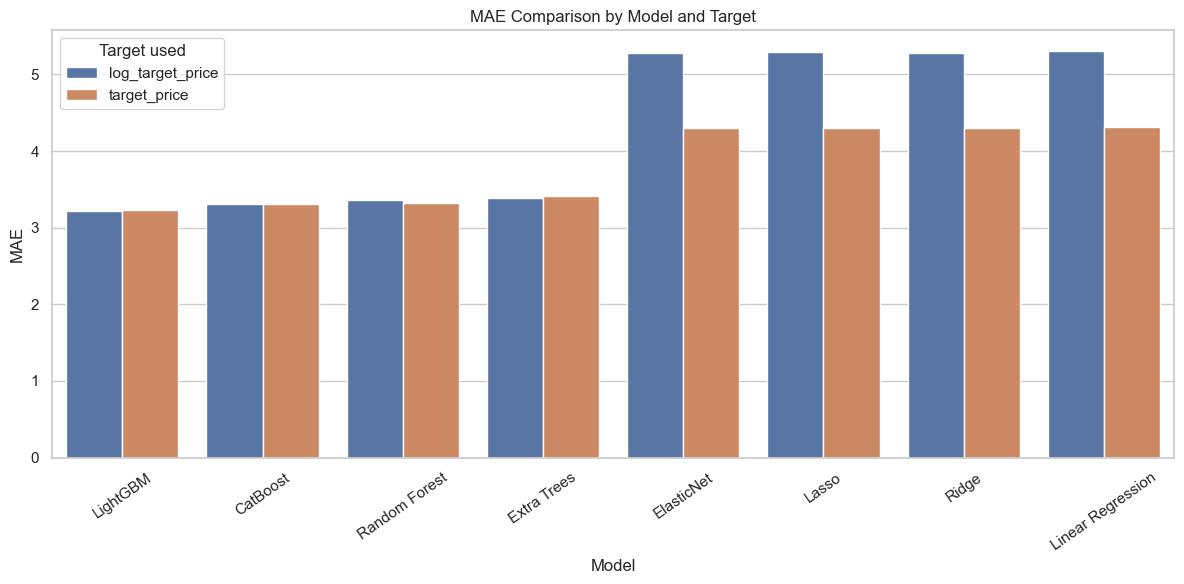

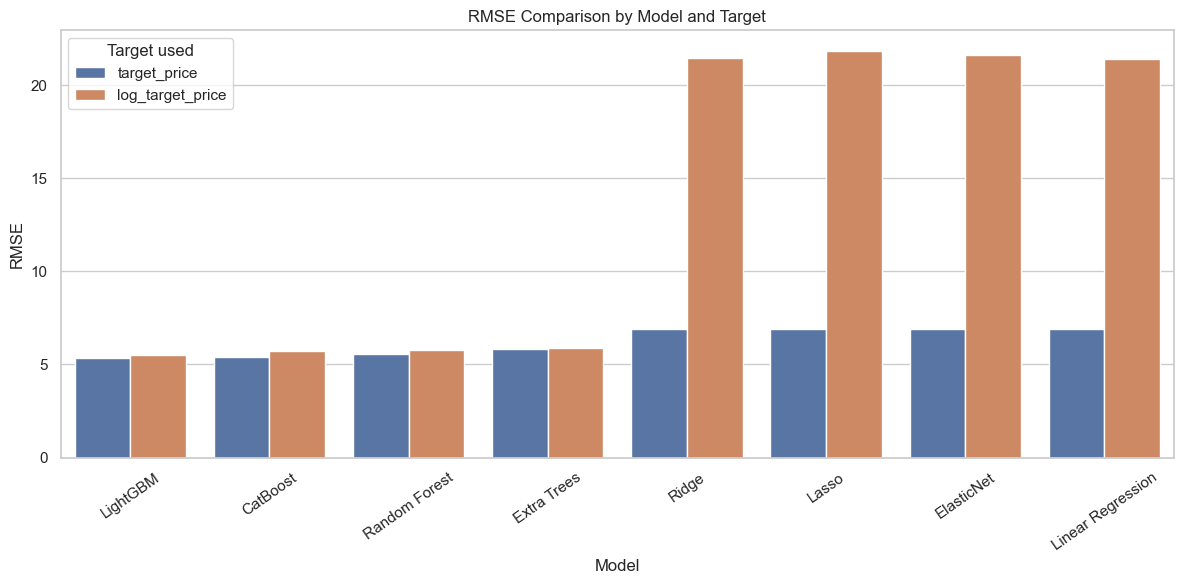

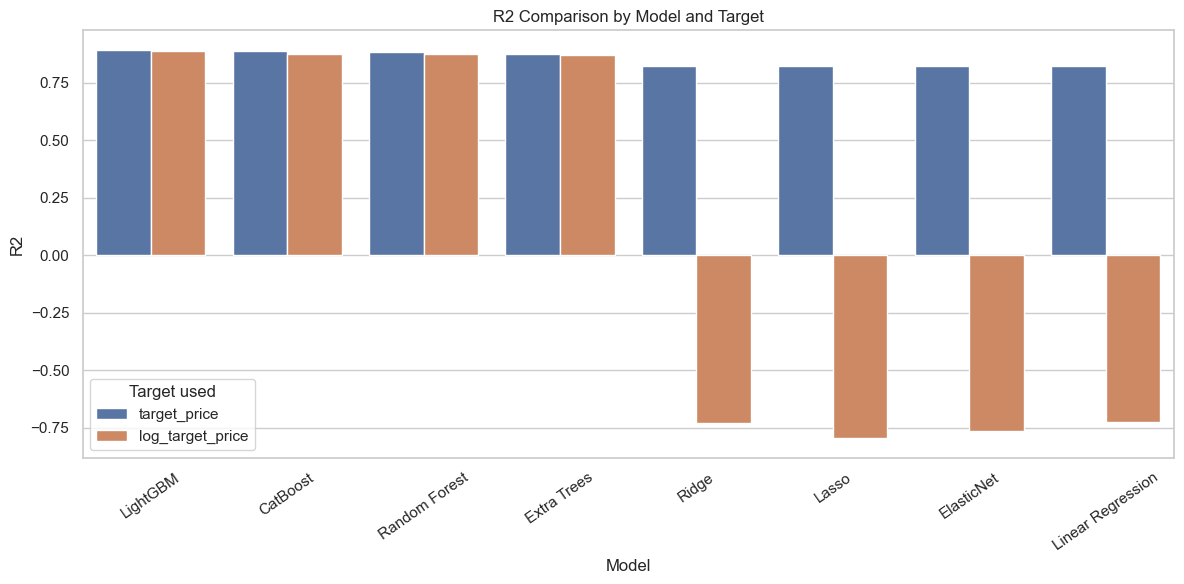

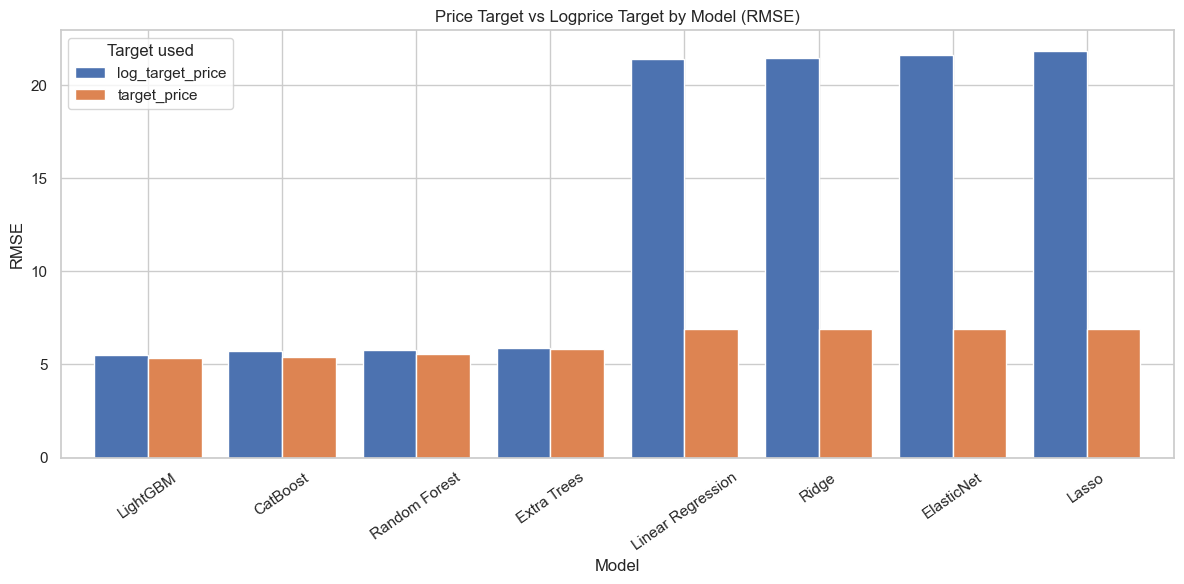

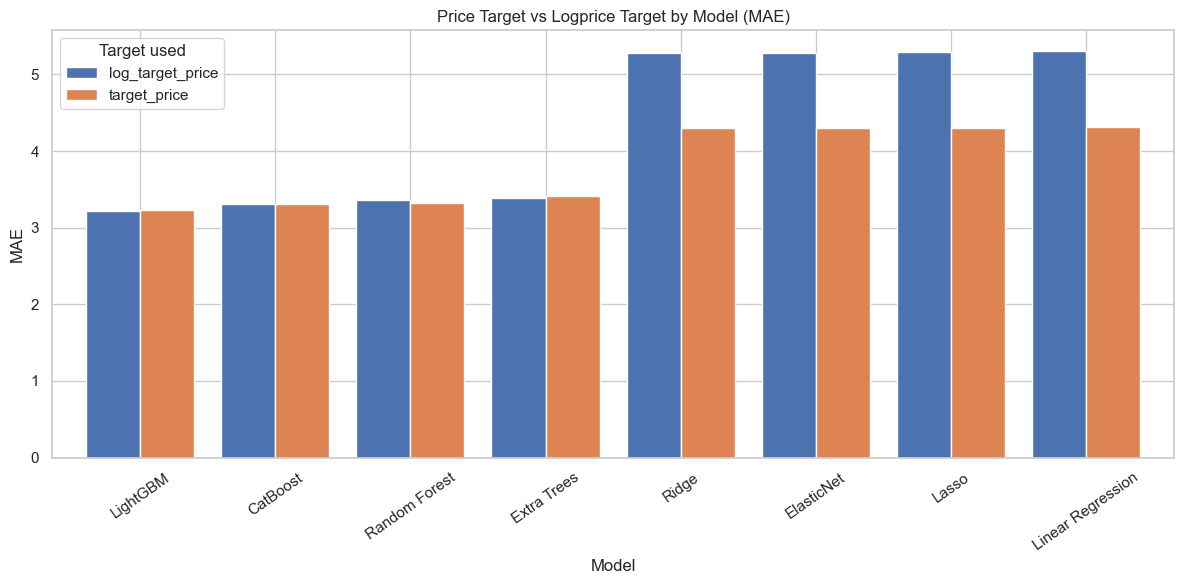

In [38]:
for metric in ['mae', 'rmse', 'r2']:
    plot_metric_comparison(metrics_df, metric)

plot_target_comparison(metrics_df, metric_name='rmse')
plot_target_comparison(metrics_df, metric_name='mae')

## Target Strategy Comparison

Các biểu đồ trên so sánh hiệu năng của các mô hình khi train trực tiếp trên `target_price` và khi train trên `log_target_price`. Với các mô hình dùng `log_target_price`, prediction đã được inverse-transform về lại thang giá thật trước khi tính MAE, RMSE và R². Do đó, các metric trong biểu đồ này đều được hiểu trên cùng thang đo giá thật, đơn vị là triệu VND.

Nhìn chung, nhóm mô hình tree-based ensemble vẫn cho kết quả tốt và ổn định hơn nhóm linear models. `LightGBM`, `CatBoost`, `Random Forest` và `Extra Trees` có RMSE thấp hơn, MAE thấp hơn và R² cao hơn rõ rệt so với các mô hình tuyến tính.

Điểm đáng chú ý nhất trong lần chạy này là nhóm linear models khi train trên `log_target_price` cho kết quả rất bất thường sau khi inverse-transform về giá thật. RMSE tăng lên rất lớn, R² bị âm, và sai số cực đại rất cao. Điều này cho thấy các mô hình tuyến tính trên log target có thể đã sinh ra một số giá trị dự đoán log quá lớn; khi chuyển ngược bằng hàm exponential, các lỗi này bị phóng đại mạnh trên thang giá thật.

### RMSE Comparison

Biểu đồ RMSE cho thấy nhóm tree-based models có RMSE tương đối thấp và ổn định, dao động quanh khoảng 5.3–5.9 triệu. Trong nhóm này, `LightGBM` là mô hình tốt nhất theo RMSE, đặc biệt khi train trực tiếp trên `target_price`.

`CatBoost` cũng có kết quả rất cạnh tranh, chỉ kém `LightGBM` một chút. `Random Forest` và `Extra Trees` thấp hơn hai mô hình boosting nhưng vẫn giữ hiệu năng khá tốt.

Ngược lại, nhóm linear models khi train trên `log_target_price` có RMSE tăng vọt lên trên 21 triệu. Đây là dấu hiệu bất thường và không nên xem các mô hình này là lựa chọn tốt trong cấu hình hiện tại. Khi train trực tiếp trên `target_price`, nhóm linear models ổn định hơn nhiều, với RMSE khoảng 6.8–6.9 triệu.

### MAE Comparison

Biểu đồ MAE cho thấy sự khác biệt giữa hai target nhỏ hơn ở nhóm tree-based models. `LightGBM`, `CatBoost`, `Random Forest` và `Extra Trees` đều có MAE quanh khoảng 3.2–3.4 triệu. Điều này cho thấy các mô hình tree-based dự đoán khá ổn định cho phần lớn mẫu trong tập test.

Ở nhóm linear models, train trực tiếp trên `target_price` cho MAE khoảng 4.3 triệu, trong khi train trên `log_target_price` làm MAE tăng lên khoảng 5.3 triệu. Như vậy, trong lần chạy này, log-transform không giúp linear models cải thiện trên thang giá thật, mà ngược lại còn làm kết quả xấu hơn.

Điều này khác với kỳ vọng thông thường rằng log target có thể giúp mô hình tuyến tính ổn định hơn. Nguyên nhân có thể đến từ việc inverse-transform làm phóng đại một số dự đoán lệch lớn, hoặc có outlier trong feature/target khiến mô hình tuyến tính dự đoán log price quá cao.

### R² Comparison

Biểu đồ R² xác nhận rõ vấn đề của nhóm linear models trên `log_target_price`. Các mô hình linear khi train trực tiếp trên `target_price` vẫn đạt R² khoảng 0.82, tức là vẫn giải thích được phần lớn biến động giá. Tuy nhiên, khi train trên `log_target_price` rồi inverse-transform về giá thật, R² giảm xuống âm.

R² âm nghĩa là mô hình còn tệ hơn việc chỉ dự đoán bằng giá trị trung bình của target trên tập test. Vì vậy, các kết quả linear + `log_target_price` trong lần chạy này cần được xem là không đạt yêu cầu trên thang giá thật.

Trong khi đó, nhóm tree-based models vẫn giữ R² cao, khoảng 0.87–0.89. `LightGBM` train trực tiếp trên `target_price` đạt R² cao nhất, tiếp theo là `CatBoost`. Điều này cho thấy các mô hình boosting vẫn là lựa chọn phù hợp nhất cho bài toán dự đoán giá laptop.

### Price Target vs Log Target

Hai biểu đồ cuối so sánh trực tiếp `target_price` và `log_target_price` theo RMSE và MAE.

Với nhóm tree-based models, sự khác biệt giữa hai chiến lược target không quá lớn. `target_price` thường nhỉnh hơn về RMSE, trong khi `log_target_price` có thể cạnh tranh về MAE ở một vài mô hình. Điều này cho thấy cả hai hướng vẫn đáng thử đối với `LightGBM` và `CatBoost`.

Tuy nhiên, với nhóm linear models, `log_target_price` cho kết quả rất xấu sau khi inverse-transform. RMSE tăng mạnh và MAE cũng cao hơn so với train trực tiếp trên `target_price`. Vì vậy, không nên sử dụng linear models với `log_target_price` trong cấu hình hiện tại nếu mục tiêu đánh giá là giá thật.

### Key Takeaways

`LightGBM` train trực tiếp trên `target_price` là mô hình tốt nhất trong lần chạy này nếu xét trên thang giá thật. Mô hình này có RMSE thấp nhất, MAE thấp nhất hoặc gần thấp nhất, và R² cao nhất.

`CatBoost` train trực tiếp trên `target_price` là lựa chọn mạnh thứ hai, có hiệu năng rất gần `LightGBM` và vẫn nên được giữ lại cho bước tuning tiếp theo.

Với nhóm tree-based models, `log_target_price` vẫn có thể được giữ lại để so sánh thêm, nhưng cần chú ý rằng RMSE trên giá thật có thể cao hơn do lỗi ở một số mẫu giá cao.

Với nhóm linear models, nên ưu tiên train trực tiếp trên `target_price`. Kết quả linear + `log_target_price` hiện tại có dấu hiệu bất thường vì RMSE rất lớn và R² âm sau khi inverse-transform.

Bước tiếp theo nên kiểm tra riêng các dòng gây lỗi lớn ở nhóm linear + `log_target_price`, đặc biệt là các mẫu có predicted price quá cao sau inverse-transform. Đồng thời, nên tiếp tục tune `LightGBM` và `CatBoost`, kết hợp residual analysis theo price range, brand, GPU type, CPU tier, condition và warranty.

## 16. Generate actual vs predicted plots for top 3 models

Scatter plot Actual vs Predicted cho top 3 model giúp kiểm tra trực quan mức độ bám sát đường lý tưởng `y = x`. Nếu điểm lệch mạnh ở vùng giá cao hoặc giá thấp, đó là dấu hiệu nên phân tích thêm theo phân khúc laptop thay vì chỉ nhìn metric tổng thể.

,model_name,target_used,rmse,mae,r2
0,LightGBM,target_price,5.3365,3.2246,0.8930
1,CatBoost,target_price,5.4136,3.3104,0.8898
2,LightGBM,log_target_price,5.5069,3.2178,0.8860


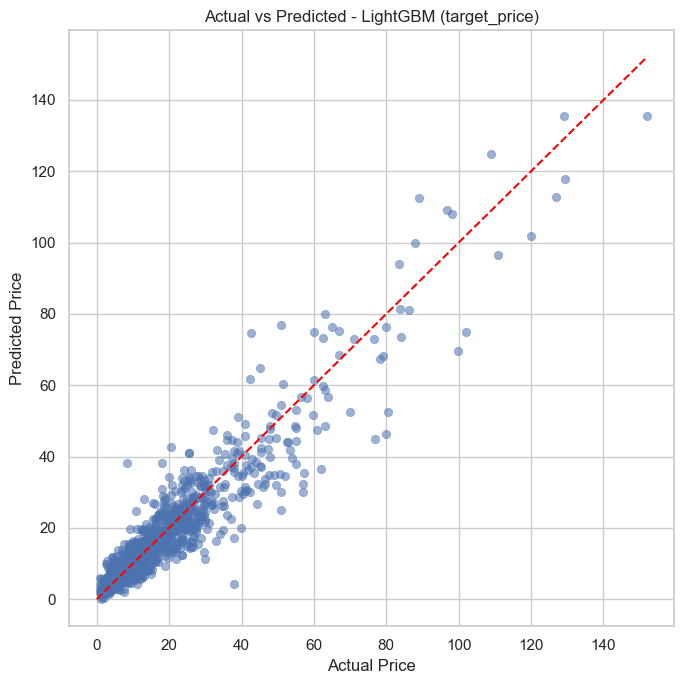

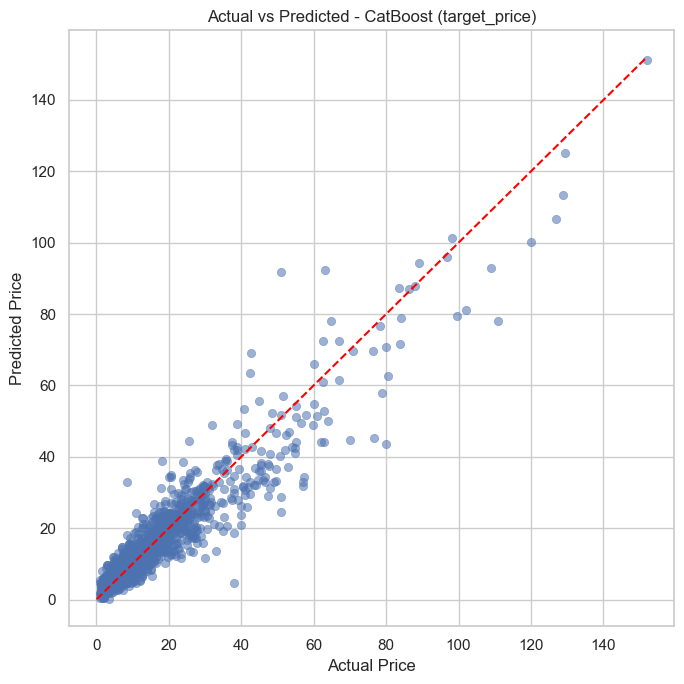

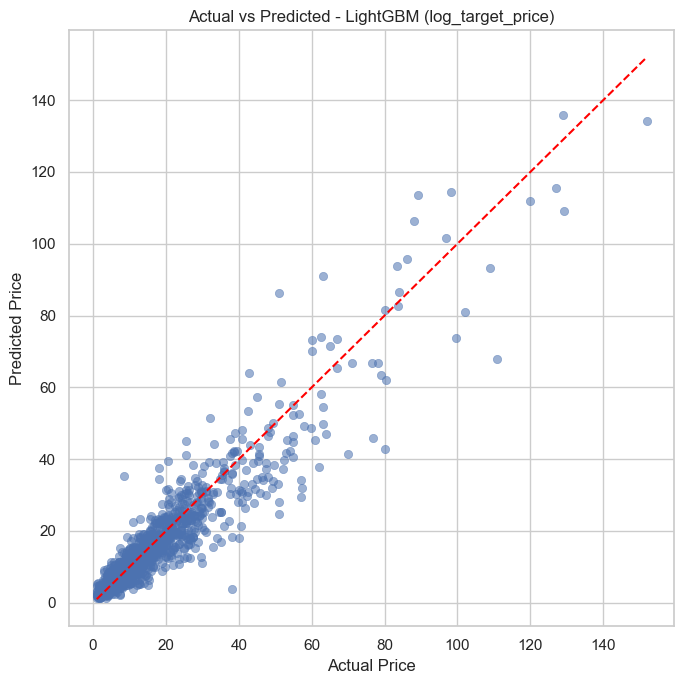

In [39]:
top_3_models = metrics_df.sort_values('rmse').head(3)[['model_name', 'target_used', 'rmse', 'mae', 'r2']]
display(top_3_models)

for _, row in top_3_models.iterrows():
    pred_col = f"pred_{safe_filename(row['model_name'], row['target_used'])}"
    plot_actual_vs_predicted(
        y_true=y_price_test,
        y_pred=predictions_df[pred_col].values,
        model_name=row['model_name'],
        target_used=row['target_used'],
    )

## Actual vs Predicted Analysis

Các biểu đồ `Actual vs Predicted` so sánh giá thật và giá dự đoán của ba mô hình tốt nhất: `LightGBM` train trên `log_target_price`, `CatBoost` train trên `target_price`, và `LightGBM` train trên `target_price`. Đường gạch đỏ biểu diễn đường dự đoán lý tưởng, tức là `predicted price = actual price`. Điểm càng nằm gần đường này thì mô hình dự đoán càng chính xác.

Vì `target_price` đã được scale về đơn vị triệu VND, cả trục `Actual Price` và `Predicted Price` đều được hiểu theo đơn vị triệu đồng.

Nhìn chung, cả ba mô hình đều học được xu hướng chính của dữ liệu. Phần lớn điểm dữ liệu tập trung quanh đường chéo, đặc biệt ở vùng giá thấp và trung bình. Điều này cho thấy các mô hình dự đoán khá tốt đối với nhóm laptop phổ biến trong tập test.

Tuy nhiên, khi giá thực tế tăng lên, độ phân tán của các điểm cũng tăng theo. Điều này cho thấy mô hình dự đoán kém ổn định hơn ở nhóm laptop giá cao, vốn thường có ít mẫu hơn, cấu hình đa dạng hơn và dễ bị ảnh hưởng bởi các yếu tố khó biểu diễn đầy đủ trong feature.

### LightGBM with `log_target_price`

Biểu đồ của `LightGBM` train trên `log_target_price` cho thấy mô hình dự đoán tốt ở vùng giá thấp và trung bình. Các điểm trong khoảng dưới 40 triệu tập trung khá sát quanh đường lý tưởng, cho thấy mô hình học tốt xu hướng tương đối của giá sau khi log-transform target.

Ở vùng giá cao, mô hình bắt đầu có sai số lớn hơn. Một số mẫu có giá thực tế cao bị dự đoán thấp hơn đáng kể, trong khi một số mẫu khác lại bị dự đoán cao hơn giá thật. Đây là pattern thường gặp khi train trên log target, vì log-transform làm giảm ảnh hưởng của các giá trị giá rất cao trong quá trình học.

Nhìn chung, `LightGBM` với `log_target_price` là mô hình ổn định ở phân khúc giá phổ biến và có thể phù hợp nếu mục tiêu là giảm sai số trung bình cho đa số mẫu.

### CatBoost with `target_price`

Biểu đồ của `CatBoost` train trực tiếp trên `target_price` cho thấy phân bố điểm khá sát đường lý tưởng. Mô hình dự đoán tốt ở vùng giá thấp đến trung bình, đặc biệt ở khoảng dưới 40 triệu, nơi dữ liệu tập trung nhiều nhất.

Ở vùng giá cao, `CatBoost` vẫn có một số điểm bị lệch khỏi đường lý tưởng, nhưng nhìn chung mô hình vẫn giữ được xu hướng tăng của giá. Một số mẫu có giá rất cao vẫn được dự đoán khá sát, cho thấy `CatBoost` có khả năng học tốt các quan hệ phi tuyến giữa đặc trưng laptop và giá bán.

So với `LightGBM`, biểu đồ của `CatBoost` nhìn khá cân bằng. Mô hình không chỉ hoạt động tốt ở vùng giá phổ biến mà còn giữ được khả năng dự đoán tương đối ổn ở một số mẫu giá cao. Đây là lý do `CatBoost` vẫn là một baseline mạnh để giữ lại cho bước tuning tiếp theo.

### LightGBM with `target_price`

Biểu đồ của `LightGBM` train trực tiếp trên `target_price` cũng cho thấy mô hình học tốt quan hệ giữa feature và giá. Các điểm ở vùng giá thấp và trung bình bám sát đường chéo, tương tự `CatBoost`.

Ở vùng giá cao, `LightGBM` có một số điểm phân tán rõ hơn. Một vài mẫu giá thực tế cao bị dự đoán thấp hơn đáng kể, tức là mô hình có xu hướng underestimate đối với một số laptop cao cấp. Tuy nhiên, cũng có một số mẫu giá cao được dự đoán khá sát, cho thấy mô hình vẫn học được xu hướng tổng quát của phân khúc này.

Nhìn tổng thể, `LightGBM` train trực tiếp trên `target_price` là mô hình rất mạnh, đặc biệt khi xét các metric tổng thể như RMSE, MAE và R² trên thang giá thật.

### Error Pattern

Các điểm nằm phía trên đường đỏ là các mẫu bị dự đoán cao hơn giá thật, tức là overprediction. Ngược lại, các điểm nằm phía dưới đường đỏ là các mẫu bị dự đoán thấp hơn giá thật, tức là underprediction.

Pattern chung của cả ba biểu đồ là sai số tăng dần khi giá thực tế tăng. Ở vùng giá thấp và trung bình, các điểm tập trung dày và bám sát đường lý tưởng hơn. Điều này cho thấy mô hình có nhiều dữ liệu để học và dự đoán ổn định hơn ở các phân khúc phổ biến.

Ngược lại, ở vùng giá cao, số lượng mẫu ít hơn và độ phân tán lớn hơn. Các laptop trong phân khúc này thường có cấu hình đặc biệt hơn, ví dụ như GPU cao cấp, workstation GPU, CPU mạnh, màn hình chất lượng cao, dòng máy premium hoặc tình trạng máy khác biệt. Nếu các yếu tố này chưa được feature engineering đầy đủ, mô hình sẽ dễ bị sai số lớn.

### Key Takeaways

Các biểu đồ xác nhận rằng `LightGBM` và `CatBoost` đều là các mô hình mạnh cho bài toán dự đoán giá laptop. Cả hai đều dự đoán tốt ở vùng giá thấp và trung bình, là khu vực chiếm phần lớn dữ liệu.

`LightGBM` train trực tiếp trên `target_price` là lựa chọn rất tốt nếu ưu tiên metric tổng thể trên thang giá thật, đặc biệt là RMSE và R².

`CatBoost` train trực tiếp trên `target_price` cũng là một baseline rất mạnh, có phân bố dự đoán khá cân bằng và vẫn giữ được xu hướng tốt ở vùng giá cao.

`LightGBM` train trên `log_target_price` vẫn đáng giữ lại để so sánh, vì mô hình có khả năng dự đoán ổn định ở vùng giá phổ biến. Tuy nhiên, cần chú ý các lỗi lớn sau khi inverse-transform, đặc biệt ở nhóm laptop giá cao.

Bước tiếp theo nên là thực hiện residual analysis trên các mẫu có sai số lớn nhất. Cần kiểm tra lỗi theo `price_range`, `brand`, `model`, `CPU tier`, `GPU type`, `condition`, `warranty` và các feature liên quan đến phân khúc premium để xác định nguyên nhân underprediction hoặc overprediction.

## 17. Generate residual and error distribution plots for top 3 models

Residual plot cho biết sai số có phân bố ngẫu nhiên hay bị lệch theo mức giá dự đoán. Error distribution plot giúp quan sát bias tổng thể: phân phối centered gần 0 là tốt, còn lệch hẳn sang một phía cho thấy model có xu hướng overestimate hoặc underestimate.

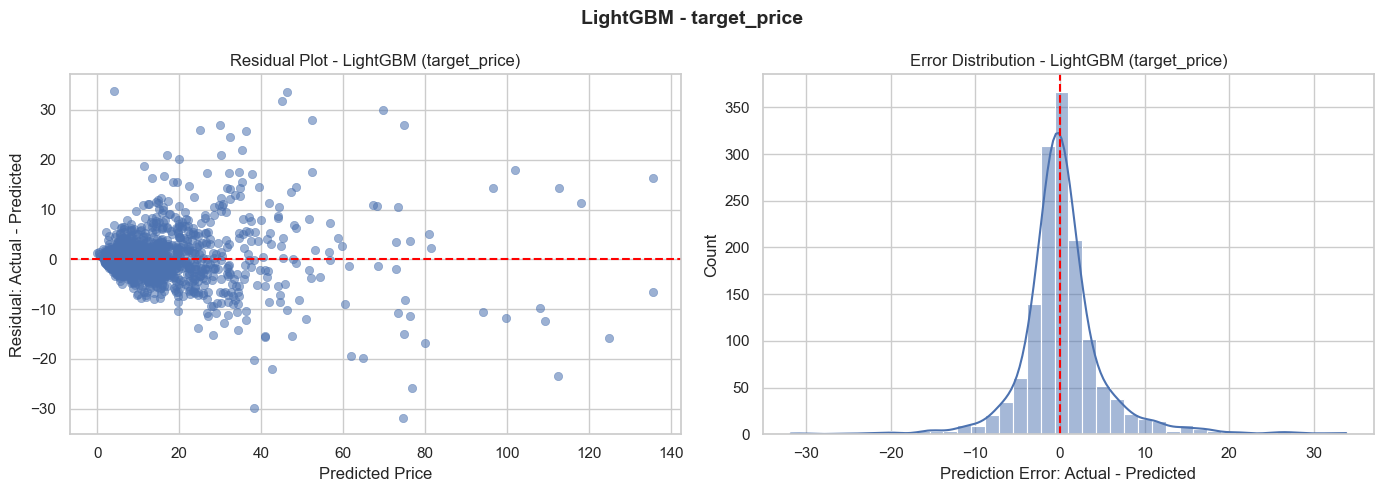

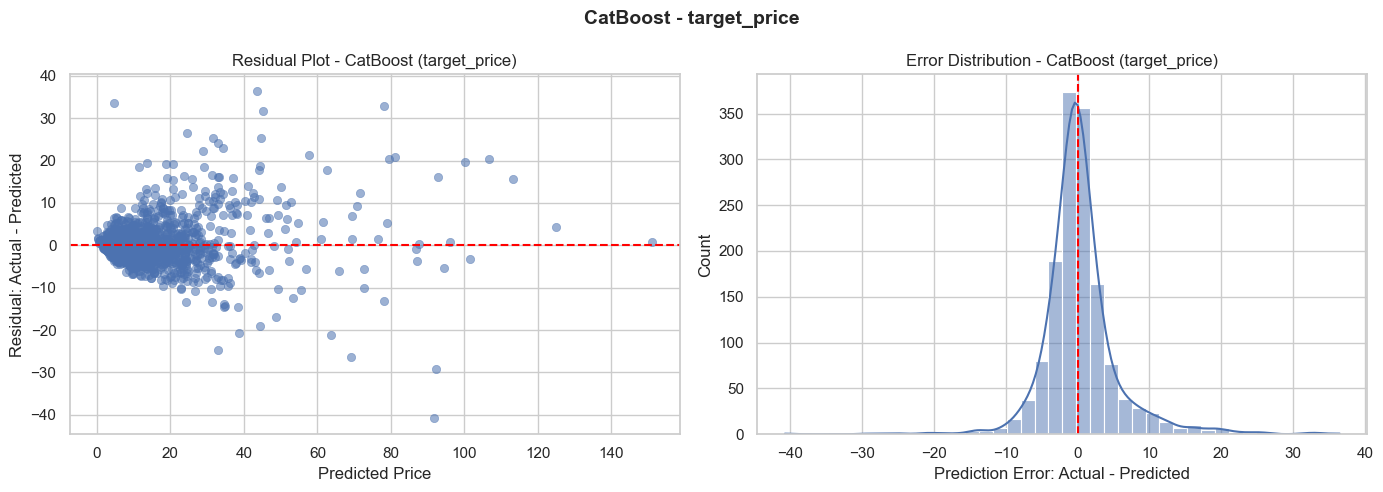

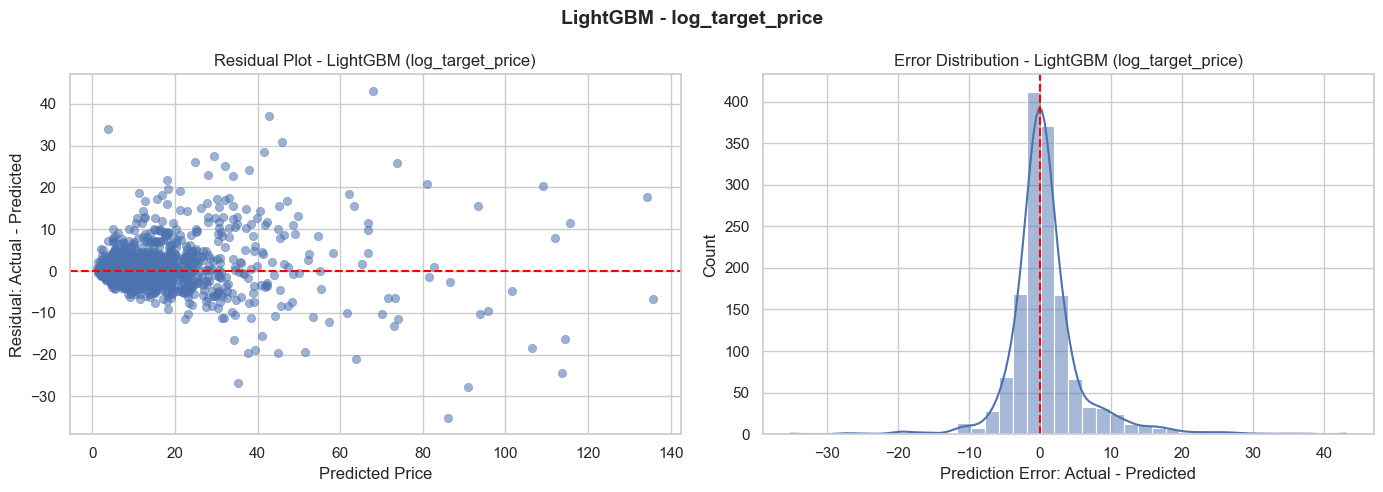

In [40]:
for _, row in top_3_models.iterrows():
    pred_col = f"pred_{safe_filename(row['model_name'], row['target_used'])}"
    y_pred_current = predictions_df[pred_col].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_residuals(
        y_true=y_price_test,
        y_pred=y_pred_current,
        model_name=row['model_name'],
        target_used=row['target_used'],
        ax=axes[0]
    )

    plot_error_distribution(
        y_true=y_price_test,
        y_pred=y_pred_current,
        model_name=row['model_name'],
        target_used=row['target_used'],
        ax=axes[1]
    )

    fig.suptitle(
        f"{row['model_name']} - {row['target_used']}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

## 18. Save feature importance / coefficients

Với tree-based model, notebook lưu `feature_importances_`; với linear model, notebook lưu coefficient table. Cột `abs_importance` hỗ trợ sắp xếp độ ảnh hưởng tuyệt đối, nhưng khi diễn giải linear coefficient vẫn nên chú ý dấu âm/dương của cột `importance`.

In [41]:
feature_importance_frames = []

for model_key, fitted_model in trained_models.items():
    model_name, target_used = model_key.rsplit('_', 1)
    importance_df = extract_feature_importance(fitted_model, model_name, feature_names)

    if importance_df is None:
        print(f'No feature importance or coefficients available for {model_key}.')
        continue

    importance_df['target_used'] = target_used
    output_columns = ['feature', 'importance', 'model_name', 'target_used', 'importance_type', 'abs_importance']
    importance_df = importance_df[output_columns]

    output_path = FEATURE_IMPORTANCE_DIR / f'{safe_filename(model_name, target_used)}_feature_importance.csv'
    importance_df.to_csv(output_path, index=False)
    feature_importance_frames.append(importance_df)
    print(f'Saved: {output_path.name}')

if feature_importance_frames:
    all_feature_importance_df = pd.concat(feature_importance_frames, ignore_index=True)
    all_feature_importance_path = FEATURE_IMPORTANCE_DIR / 'all_feature_importance.csv'
    all_feature_importance_df.to_csv(all_feature_importance_path, index=False)
    display(all_feature_importance_df.head(20))
else:
    all_feature_importance_df = pd.DataFrame()

Saved: LinearRegression_target_price_feature_importance.csv
Saved: LinearRegression_log_target_price_feature_importance.csv
Saved: Ridge_target_price_feature_importance.csv
Saved: Ridge_log_target_price_feature_importance.csv
Saved: Lasso_target_price_feature_importance.csv
Saved: Lasso_log_target_price_feature_importance.csv
Saved: ElasticNet_target_price_feature_importance.csv
Saved: ElasticNet_log_target_price_feature_importance.csv
Saved: RandomForest_target_price_feature_importance.csv
Saved: RandomForest_log_target_price_feature_importance.csv
Saved: ExtraTrees_target_price_feature_importance.csv
Saved: ExtraTrees_log_target_price_feature_importance.csv
Saved: LightGBM_target_price_feature_importance.csv
Saved: LightGBM_log_target_price_feature_importance.csv
Saved: CatBoost_target_price_feature_importance.csv
Saved: CatBoost_log_target_price_feature_importance.csv


,feature,importance,model_name,target_used,importance_type,abs_importance
0,brand_Dell,"63,940,602,766,430.1406",Linear Regression_target,price,coefficient,"63,940,602,766,430.1406"
1,brand_Lenovo,"50,256,371,573,601.2266",Linear Regression_target,price,coefficient,"50,256,371,573,601.2266"
2,brand_Apple,"49,643,930,897,436.2422",Linear Regression_target,price,coefficient,"49,643,930,897,436.2422"
3,brand_HP,"47,854,099,337,202.6094",Linear Regression_target,price,coefficient,"47,854,099,337,202.6094"
4,brand_ASUS,"46,580,568,160,091.8984",Linear Regression_target,price,coefficient,"46,580,568,160,091.8984"
5,brand_Acer,"35,913,662,684,448.6406",Linear Regression_target,price,coefficient,"35,913,662,684,448.6406"
6,cpu_brand_Other,"32,576,745,732,903.8008",Linear Regression_target,price,coefficient,"32,576,745,732,903.8008"
7,brand_MSI,"29,287,523,613,592.9453",Linear Regression_target,price,coefficient,"29,287,523,613,592.9453"
8,no_info_cpu_brand,"-27,966,359,876,658.8398",Linear Regression_target,price,coefficient,"27,966,359,876,658.8398"
9,brand_Microsoft,"26,538,500,774,946.1484",Linear Regression_target,price,coefficient,"26,538,500,774,946.1484"


## 19. Summary of best models

Phần cuối notebook tổng hợp top model theo RMSE và MAE, so sánh `price` với `logprice` trong từng thuật toán, rồi in kết luận tự động. Kết luận có kiểm tra khoảng cách giữa các model top đầu; nếu chênh lệch nhỏ, notebook sẽ ghi rõ rằng kết quả nên được xem là sát nhau thay vì khẳng định tuyệt đối.

In [42]:
top_by_rmse = metrics_df.sort_values('rmse').head(10).reset_index(drop=True)
top_by_mae = metrics_df.sort_values('mae').head(10).reset_index(drop=True)

display(top_by_rmse)
display(top_by_mae)

# Compare price vs logprice target for each model.
target_comparison_rows = []
for model_name, group in metrics_df.groupby('model_name'):
    pivot = group.set_index('target_used')
    if {'target_price', 'log_target_price'}.issubset(pivot.index):
        price_rmse = pivot.loc['target_price', 'rmse']
        log_rmse = pivot.loc['log_target_price', 'rmse']
        price_mae = pivot.loc['target_price', 'mae']
        log_mae = pivot.loc['log_target_price', 'mae']
        target_comparison_rows.append(
            {
                'model_name': model_name,
                'price_rmse': price_rmse,
                'logprice_rmse': log_rmse,
                'rmse_winner': 'log_target_price' if log_rmse < price_rmse else 'target_price',
                'rmse_pct_diff_log_vs_price': (log_rmse - price_rmse) / price_rmse,
                'price_mae': price_mae,
                'logprice_mae': log_mae,
                'mae_winner': 'log_target_price' if log_mae < price_mae else 'target_price',
                'mae_pct_diff_log_vs_price': (log_mae - price_mae) / price_mae,
            }
        )

target_comparison_df = pd.DataFrame(target_comparison_rows).sort_values('model_name')
display(target_comparison_df)

best_rmse_row = metrics_df.loc[metrics_df['rmse'].idxmin()]
best_mae_row = metrics_df.loc[metrics_df['mae'].idxmin()]

target_summary = metrics_df.groupby('target_used')[['rmse', 'mae', 'r2']].mean().sort_values('rmse')
best_target_overall = target_summary.index[0]

rmse_gap = (
    metrics_df.sort_values('rmse').iloc[1]['rmse'] - best_rmse_row['rmse']
) / best_rmse_row['rmse'] if len(metrics_df) > 1 else np.nan

mae_gap = (
    metrics_df.sort_values('mae').iloc[1]['mae'] - best_mae_row['mae']
) / best_mae_row['mae'] if len(metrics_df) > 1 else np.nan

print('Automatic conclusion')
print('--------------------')
print(
    f"Best model by RMSE: {best_rmse_row['model_name']} trained on {best_rmse_row['target_used']} "
    f"with RMSE={best_rmse_row['rmse']:,.4f}, MAE={best_rmse_row['mae']:,.4f}, R2={best_rmse_row['r2']:,.4f}."
)
print(
    f"Best model by MAE : {best_mae_row['model_name']} trained on {best_mae_row['target_used']} "
    f"with MAE={best_mae_row['mae']:,.4f}, RMSE={best_mae_row['rmse']:,.4f}, R2={best_mae_row['r2']:,.4f}."
)
print(f"Best target overall by average RMSE across models: {best_target_overall}.")

if not np.isnan(rmse_gap) and rmse_gap < 0.02:
    print('RMSE difference between the top two variants is below 2%, so the winner should be treated as a close result.')
if not np.isnan(mae_gap) and mae_gap < 0.02:
    print('MAE difference between the top two variants is below 2%, so the winner should be treated as a close result.')

if best_target_overall == 'log_target_price':
    print('Recommendation: logprice is currently preferable on average, but confirm with residual plots and business tolerance for large-price errors.')
else:
    print('Recommendation: direct price modeling is currently preferable on average, but confirm with residual plots and segment-level errors.')

,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,LightGBM,gradient_boosting,target_price,target_price,3.2246,5.3365,0.8930,0.2734,1.8200,33.8460,0.6659,0.0078
1,CatBoost,gradient_boosting,target_price,target_price,3.3104,5.4136,0.8898,0.2912,1.9472,40.7371,1.1658,0.0037
2,LightGBM,gradient_boosting,log_target_price,target_price,3.2178,5.5069,0.8860,0.2517,1.7537,43.1585,0.3645,0.0132
3,Random Forest,tree_ensemble,target_price,target_price,3.3197,5.5824,0.8829,0.2903,1.8316,45.1167,1.4286,0.1108
4,CatBoost,gradient_boosting,log_target_price,target_price,3.3062,5.7275,0.8767,0.2544,1.7231,40.0861,1.3581,0.0029
5,Random Forest,tree_ensemble,log_target_price,target_price,3.3611,5.7696,0.8749,0.2704,1.8100,49.2344,1.4979,0.1033
6,Extra Trees,tree_ensemble,target_price,target_price,3.4130,5.8066,0.8733,0.2963,1.9701,62.1980,1.7264,0.0737
7,Extra Trees,tree_ensemble,log_target_price,target_price,3.3826,5.8887,0.8697,0.2804,1.8000,61.1935,1.7242,0.0938
8,Ridge,linear,target_price,target_price,4.2948,6.8808,0.8220,0.3922,2.5040,56.9995,0.0264,0.0034
9,Lasso,linear,target_price,target_price,4.2943,6.8819,0.8220,0.3920,2.5057,57.0195,0.4701,0.0020


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,LightGBM,gradient_boosting,log_target_price,target_price,3.2178,5.5069,0.8860,0.2517,1.7537,43.1585,0.3645,0.0132
1,LightGBM,gradient_boosting,target_price,target_price,3.2246,5.3365,0.8930,0.2734,1.8200,33.8460,0.6659,0.0078
2,CatBoost,gradient_boosting,log_target_price,target_price,3.3062,5.7275,0.8767,0.2544,1.7231,40.0861,1.3581,0.0029
3,CatBoost,gradient_boosting,target_price,target_price,3.3104,5.4136,0.8898,0.2912,1.9472,40.7371,1.1658,0.0037
4,Random Forest,tree_ensemble,target_price,target_price,3.3197,5.5824,0.8829,0.2903,1.8316,45.1167,1.4286,0.1108
5,Random Forest,tree_ensemble,log_target_price,target_price,3.3611,5.7696,0.8749,0.2704,1.8100,49.2344,1.4979,0.1033
6,Extra Trees,tree_ensemble,log_target_price,target_price,3.3826,5.8887,0.8697,0.2804,1.8000,61.1935,1.7242,0.0938
7,Extra Trees,tree_ensemble,target_price,target_price,3.4130,5.8066,0.8733,0.2963,1.9701,62.1980,1.7264,0.0737
8,ElasticNet,linear,target_price,target_price,4.2943,6.8824,0.8219,0.3920,2.4961,57.0174,3.5194,0.0022
9,Lasso,linear,target_price,target_price,4.2943,6.8819,0.8220,0.3920,2.5057,57.0195,0.4701,0.0020


,model_name,price_rmse,logprice_rmse,rmse_winner,rmse_pct_diff_log_vs_price,price_mae,logprice_mae,mae_winner,mae_pct_diff_log_vs_price
0,CatBoost,5.4136,5.7275,target_price,0.0580,3.3104,3.3062,log_target_price,-0.0013
1,ElasticNet,6.8824,21.6508,target_price,2.1458,4.2943,5.2848,target_price,0.2307
2,Extra Trees,5.8066,5.8887,target_price,0.0141,3.4130,3.3826,log_target_price,-0.0089
3,Lasso,6.8819,21.8528,target_price,2.1754,4.2943,5.2943,target_price,0.2329
4,LightGBM,5.3365,5.5069,target_price,0.0319,3.2246,3.2178,log_target_price,-0.0021
5,Linear Regression,6.9019,21.4264,target_price,2.1044,4.3090,5.3084,target_price,0.2319
6,Random Forest,5.5824,5.7696,target_price,0.0335,3.3197,3.3611,target_price,0.0125
7,Ridge,6.8808,21.4393,target_price,2.1158,4.2948,5.2819,target_price,0.2298


Automatic conclusion
--------------------
Best model by RMSE: LightGBM trained on target_price with RMSE=5.3365, MAE=3.2246, R2=0.8930.
Best model by MAE : LightGBM trained on log_target_price with MAE=3.2178, RMSE=5.5069, R2=0.8860.
Best target overall by average RMSE across models: target_price.
RMSE difference between the top two variants is below 2%, so the winner should be treated as a close result.
MAE difference between the top two variants is below 2%, so the winner should be treated as a close result.
Recommendation: direct price modeling is currently preferable on average, but confirm with residual plots and segment-level errors.
